In [1]:
# Suppress red warning messages to keep the notebook output clean during the presentation
import warnings
warnings.filterwarnings("ignore")

# Bring in the core Python libraries for loading and manipulating data tables
import pandas as pd
import numpy as np

# Bring in the visualization libraries we will need to draw our graphs
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset into a Pandas DataFrame
df = pd.read_csv("9598_Job_postings.csv")

# Inspect the top and bottom rows to verify successful loading
print("First 5 rows of the dataset:")
display(df.head())

print("Last 5 rows of the dataset:")
display(df.tail())

# Extract a list of all column names for reference
print("\nList of all Column Names:")
print(df.columns.tolist())

# Display core dataset information including data types and missing values
print("\n" + "="*50)
print("Detailed Dataset Information (Data types & missing values):")
df.info()
print("="*50 + "\n")

# Perform a baseline audit for dataset dimensions and duplicate records
print("Dataset Shape (Rows, Columns):", df.shape)
print("Number of duplicate rows:", df.duplicated().sum())

# Check the cardinality of key categorical columns
print("\nNumber of unique job titles:", df["job_title"].nunique())
print("Number of companies:", df["company_id"].nunique())
print("Number of locations:", df["job_location"].nunique())
print("Number of countries:", df["job_country"].nunique())

First 5 rows of the dataset:


,job_id,company_id,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg
0,22460,11335,Data Analyst,Student Worker/Intern - Data Analysis,"Dallas, TX",via ZipRecruiter,Part-time and Internship,False,Sudan,2023-09-27 11:17:46,False,False,Sudan,hour,NaN,8.0
1,309481,13217,Data Analyst,Online Data Analyst for Digital Maps (English ...,Anywhere,via Get.It,Contractor,True,Taiwan,2023-12-13 11:46:47,True,False,Taiwan,hour,NaN,8.0
2,455027,647,Data Analyst,data analyst,"Malvern, PA",via Indeed,Contractor,False,"New York, United States",2023-01-17 22:00:20,False,True,United States,hour,NaN,8.5
3,891573,501507,Data Analyst,Data Analyst,"Bulawayo, Zimbabwe",via Job Today,Part-time,False,Zimbabwe,2023-06-09 22:36:21,True,False,Zimbabwe,hour,NaN,9.0
4,59908,13217,Data Analyst,Remote Data Analyst (Entry-Level) for Japan Ma...,"Kobe, Hyogo, Japan",via Get.It,Part-time,False,Japan,2023-11-23 11:33:02,True,False,Japan,hour,NaN,10.0


Last 5 rows of the dataset:


,job_id,company_id,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg
9593,1590388,105083,Data Analyst,Data Analyst (2178),"Natick, MA",via ZipRecruiter,Full-time,False,"New York, United States",2023-06-14 21:00:47,False,False,United States,year,72208.5,NaN
9594,112555,845,Data Analyst,Data Analyst,"Fort Meade, MD",via BeBee,Full-time,False,Georgia,2023-11-27 22:25:55,False,True,United States,year,100000.0,NaN
9595,1605882,105201,Data Analyst,Research Data Analyst III - Office of Public H...,"Sacramento, CA",via LinkedIn,Full-time,False,"California, United States",2023-03-03 21:01:25,False,False,United States,year,107800.0,NaN
9596,1612607,105268,Data Analyst,Data Analyst / Teacher Wanted,"Richardson, TX",via Indeed,Full-time,False,"Texas, United States",2023-02-22 21:00:41,True,True,United States,year,45000.0,NaN
9597,1621216,3102,Data Analyst,Data Analyst (Aberdeen-based),"Aberdeen, UK",via Ai-Jobs.net,Full-time,False,United Kingdom,2023-01-30 21:14:42,False,False,United Kingdom,year,98500.0,NaN



List of all Column Names:
['job_id', 'company_id', 'job_title_short', 'job_title', 'job_location', 'job_via', 'job_schedule_type', 'job_work_from_home', 'search_location', 'job_posted_date', 'job_no_degree_mention', 'job_health_insurance', 'job_country', 'salary_rate', 'salary_year_avg', 'salary_hour_avg']

Detailed Dataset Information (Data types & missing values):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9598 entries, 0 to 9597
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_id                 9598 non-null   int64  
 1   company_id             9598 non-null   int64  
 2   job_title_short        9598 non-null   object 
 3   job_title              9598 non-null   object 
 4   job_location           9484 non-null   object 
 5   job_via                9589 non-null   object 
 6   job_schedule_type      9503 non-null   object 
 7   job_work_from_home     9598 non-null   bool   
 8 

In [3]:
# Calculate the total count and percentage of missing data for every column
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

# Display the clean, formatted summary table for the panel to review
display(missing_summary)

,Missing Values,Missing Percentage
job_id,0,0.00
company_id,0,0.00
job_title_short,0,0.00
job_title,0,0.00
job_location,114,1.19
job_via,9,0.09
job_schedule_type,95,0.99
job_work_from_home,0,0.00
search_location,0,0.00
job_posted_date,0,0.00


In [4]:
# Inspect the original state of the date column before transformation
print("BEFORE: Original Date Column")
print("Data type:", df["job_posted_date"].dtype, "(This means it's just plain text!)")

# Display a sample of the raw text dates
display(df[["job_title", "job_posted_date"]].head(3))

print("\n" + "="*60 + "\n")

# Convert the raw text strings into proper pandas datetime objects for time-series analysis
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

# Extract the year and month components into dedicated columns to enable seasonal trend analysis
df["posting_year"] = df["job_posted_date"].dt.year
df["posting_month"] = df["job_posted_date"].dt.month

# Validate the transformation by inspecting the updated data types and new columns
print("AFTER: Converted Date with New Year and Month Columns")
print("New Data type:", df["job_posted_date"].dtype, "(Success! It is now a proper datetime)")

# Show the new columns alongside the original to prove the feature engineering worked
display(df[["job_title", "job_posted_date", "posting_year", "posting_month"]].head(3))

BEFORE: Original Date Column
Data type: object (This means it's just plain text!)


,job_title,job_posted_date
0,Student Worker/Intern - Data Analysis,2023-09-27 11:17:46
1,Online Data Analyst for Digital Maps (English ...,2023-12-13 11:46:47
2,data analyst,2023-01-17 22:00:20




AFTER: Converted Date with New Year and Month Columns
New Data type: datetime64[ns] (Success! It is now a proper datetime)


,job_title,job_posted_date,posting_year,posting_month
0,Student Worker/Intern - Data Analysis,2023-09-27 11:17:46,2023,9
1,Online Data Analyst for Digital Maps (English ...,2023-12-13 11:46:47,2023,12
2,data analyst,2023-01-17 22:00:20,2023,1


In [5]:
# Inspect the original state of the schedule column before feature engineering
print("BEFORE: The messy original text column")

# Display a sample of the raw, unstructured text data
display(df[["job_title", "job_schedule_type"]].head())

print("\n" + "="*70 + "\n")

# Define the exact job schedules identified during initial data exploration
schedule_types = [
    "Full-time", "Part-time", "Internship", "Contractor", 
    "Temp work", "Per diem", "Volunteer"
]

# Iterate through the categories to dynamically generate boolean flag columns
for schedule in schedule_types:
    
    # Standardize the string format to create clean, programmatic column names
    col_name = "is_{}".format(schedule.lower().replace('-', '_').replace(' ', '_'))
    
    # Scan the raw text and flag rows containing the specific schedule type (ignoring case)
    df[col_name] = df["job_schedule_type"].str.contains(schedule, case=False, na=False)

# Validate the transformation by inspecting the newly generated boolean columns
print("AFTER: The new True/False columns automatically added")

# Display the original text alongside the engineered flags to visually confirm accuracy
display(df[["job_schedule_type", "is_full_time", "is_part_time", "is_internship"]].head())

BEFORE: The messy original text column


,job_title,job_schedule_type
0,Student Worker/Intern - Data Analysis,Part-time and Internship
1,Online Data Analyst for Digital Maps (English ...,Contractor
2,data analyst,Contractor
3,Data Analyst,Part-time
4,Remote Data Analyst (Entry-Level) for Japan Ma...,Part-time




AFTER: The new True/False columns automatically added


,job_schedule_type,is_full_time,is_part_time,is_internship
0,Part-time and Internship,False,True,True
1,Contractor,False,False,False
2,Contractor,False,False,False
3,Part-time,False,True,False
4,Part-time,False,True,False


BEFORE: Raw, messy text counts (Notice the mixed categories!)


,Raw Schedule Text,Count
0,Full-time,6960
1,Contractor,1539
2,Full-time and Part-time,496
3,Part-time,123
4,Contractor and Temp work,114
5,Full-time and Contractor,65
6,Temp work,44
7,Full-time and Temp work,38




AFTER: Perfectly separated counts in a matching clean table


,Job Schedule,Job Count
0,Full-time,7642
1,Part-time,675
2,Internship,92
3,Contractor,1739
4,Temp work,217
5,Per diem,4
6,Volunteer,1


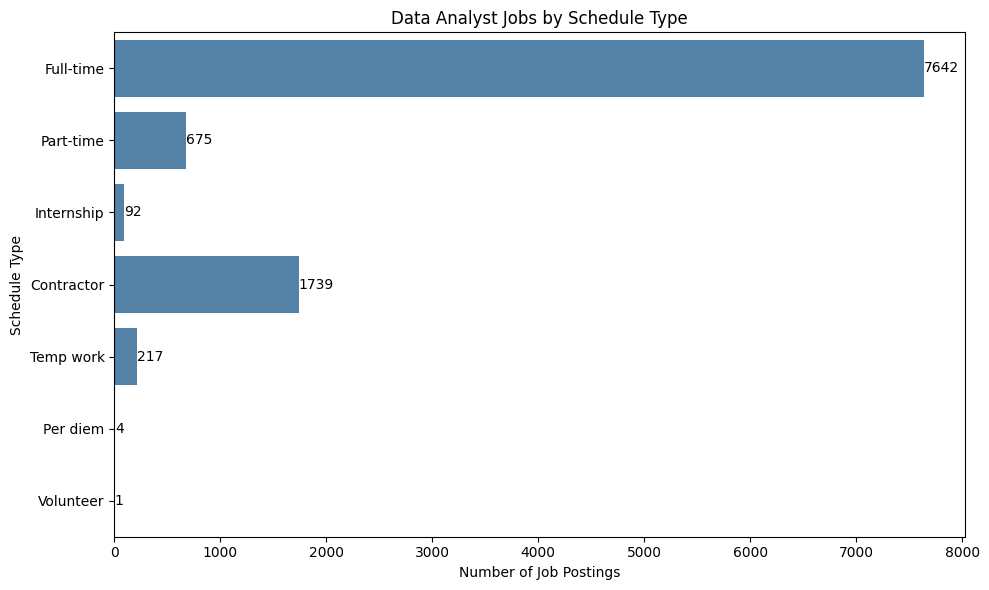

In [6]:
# Inspect the original state of the schedule distribution before cleaning
print("BEFORE: Raw, messy text counts (Notice the mixed categories!)")

# Convert the raw Pandas Series into a structured DataFrame for a clean visual comparison
raw_counts = df["job_schedule_type"].value_counts().to_frame().reset_index()
raw_counts.columns = ["Raw Schedule Text", "Count"]
display(raw_counts.head(8))

print("\n" + "="*70 + "\n")

# Aggregate the engineered boolean flags into a clean summary table
schedule_summary = pd.DataFrame({
    "Job Schedule": schedule_types,
    "Job Count": [df["is_{}".format(s.lower().replace('-', '_').replace(' ', '_'))].sum() for s in schedule_types]
})

# Validate the transformation by inspecting the standardized output
print("AFTER: Perfectly separated counts in a matching clean table")

# Display the structured summary to visually confirm the distinct categories
display(schedule_summary)

# Visualize the cleaned schedule distribution
plt.figure(figsize=(10,6))
ax = sns.barplot(data=schedule_summary, x="Job Count", y="Job Schedule", color="steelblue")

# Append exact numerical labels to each bar for precise reporting
ax.bar_label(ax.containers[0])

# Apply professional formatting, axis labels, and layout adjustments
plt.title("Data Analyst Jobs by Schedule Type")
plt.xlabel("Number of Job Postings")
plt.ylabel("Schedule Type")
plt.tight_layout()

# Render the final visualization for the panel
plt.show()

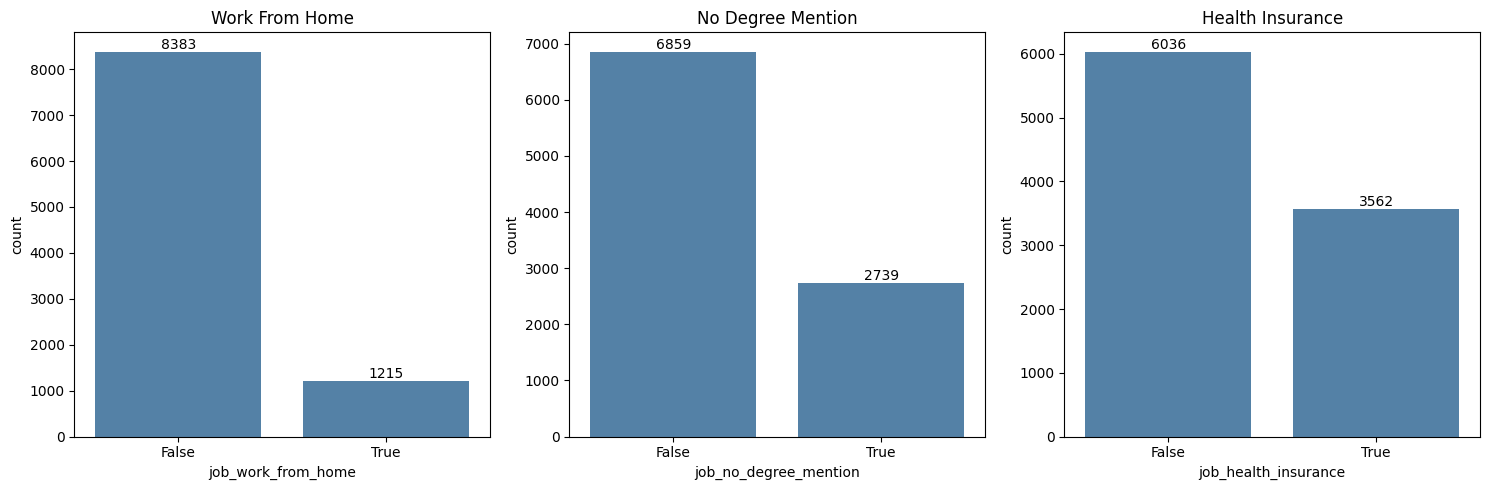

In [7]:
# Visualize binary corporate requirements: remote work availability, degree expectations, and health benefits
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Generate individual count plots for each specific job characteristic across the grid
sns.countplot(data=df, x="job_work_from_home", color="steelblue", ax=axes[0]).set_title("Work From Home")
sns.countplot(data=df, x="job_no_degree_mention", color="steelblue", ax=axes[1]).set_title("No Degree Mention")
sns.countplot(data=df, x="job_health_insurance", color="steelblue", ax=axes[2]).set_title("Health Insurance")

# Iterate through the subplot array to dynamically append exact numerical counts to every bar
for ax in axes:
    ax.bar_label(ax.containers[0])

# Optimize the layout spacing to prevent overlapping text and render the consolidated dashboard
plt.tight_layout()
plt.show()

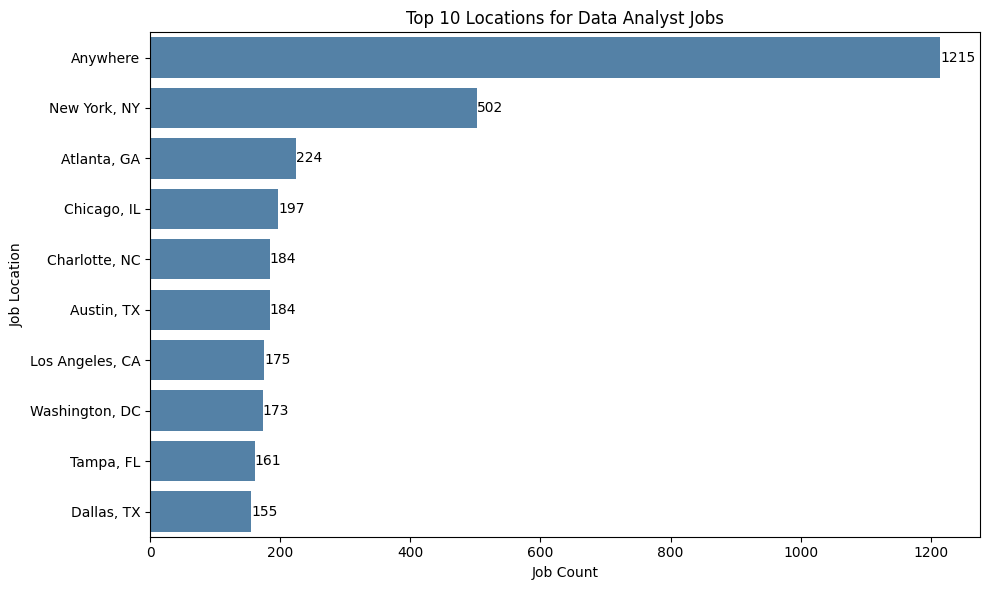

In [8]:
# Aggregate job postings by location to identify the highest demand geographic markets
location_summary = df["job_location"].value_counts().head(10).reset_index()

# Apply professional column names to the summary table for clear presentation
location_summary.columns = ["Job Location", "Job Count"]

# Initialize a horizontal bar chart to visualize the geographic distribution
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=location_summary, x="Job Count", y="Job Location", color="steelblue")

# Append exact numerical counts to the end of each bar for precise readability
ax.bar_label(ax.containers[0])

# Apply final formatting, titling, and layout adjustments to ensure a polished render
plt.title("Top 10 Locations for Data Analyst Jobs")
plt.tight_layout()

# Display the finalized geographic visualization to the panel
plt.show()

,Month,Job Count
0,January,982
1,February,681
2,March,774
3,April,744
4,May,757
5,June,932
6,July,850
7,August,1040
8,September,738
9,October,793


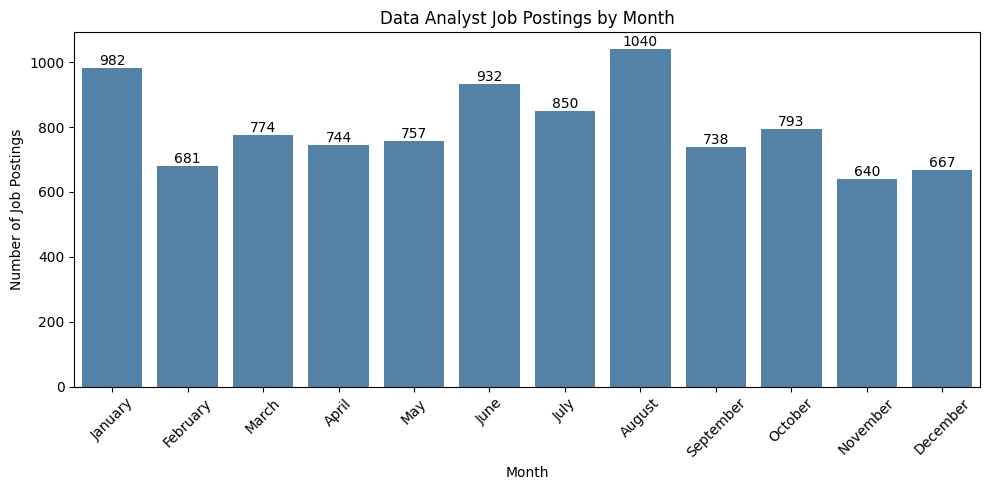

In [9]:
# Define the chronological calendar sequence to enforce logical ordering
month_order = [
    "January", "February", "March", "April", "May", "June", 
    "July", "August", "September", "October", "November", "December"
]

# Aggregate the data and apply the predefined index to ensure proper calendar alignment
monthly_jobs = df["job_posted_date"].dt.month_name().value_counts().reindex(month_order)

# Format the cleaned, sequenced data into a structured presentation table
clean_months = monthly_jobs.reset_index()
clean_months.columns = ["Month", "Job Count"]

# Display the structured summary to validate the chronological trend
display(clean_months)

print("\n" + "="*70 + "\n")

# Visualize the temporal hiring trends across the calendar year
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=monthly_jobs.index, y=monthly_jobs.values, color="steelblue")

# Append exact numerical labels to support precise data reporting
ax.bar_label(ax.containers[0])

# Apply professional formatting and rotate x-axis labels to prevent text overlap
plt.title("Data Analyst Job Postings by Month")
plt.xlabel("Month")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45)
plt.tight_layout()

# Render the final chronological visualization for the panel
plt.show()

BEFORE: We only have meaningless Company IDs!


,Company ID,Job Count
0,797,379
1,156,221
2,2686,165
3,66,94
4,453,72
5,483,58
6,9556,55
7,1689,54
8,49,53
9,1364,51




AFTER: We successfully merged the files to reveal the Company Names!


,Company Name,Job Count
0,Robert Half,379
1,Insight Global,221
2,Get It Recruit - Information Technology,165
3,Citi,94
4,Jobot,72
5,Bosch Group,58
6,"Acadia Technologies, Inc.",55
7,Aston Carter,54
8,Booz Allen Hamilton,53
9,Apex Systems,51


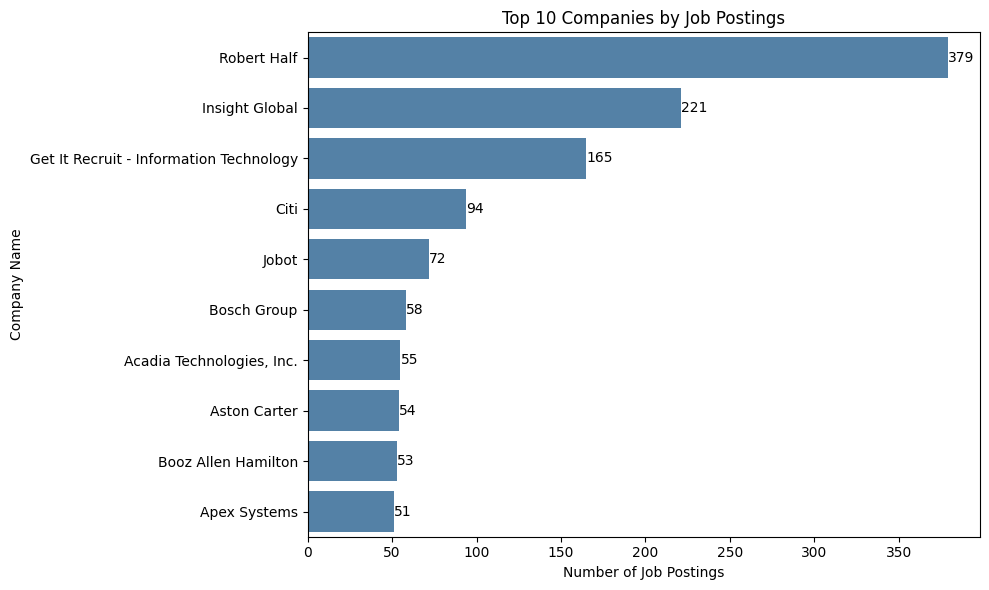

In [10]:
# Inspect the initial summary containing only raw, numeric Company IDs
print("BEFORE: We only have meaningless Company IDs!")

# Aggregate the top 10 companies by volume, noting the lack of human-readable identifiers
company_summary = df["company_id"].value_counts().head(10).reset_index()
company_summary.columns = ["Company ID", "Job Count"]
display(company_summary)

print("\n" + "="*70 + "\n")

# Import the company dimension table to map internal IDs to actual corporate names
company_dim = pd.read_csv("company_dim.csv")

# Execute a left join to enrich the summary table with descriptive company data
company_summary_merged = company_summary.merge(
    company_dim, left_on="Company ID", right_on="company_id", how="left"
)

# Validate the successful join operation
print("AFTER: We successfully merged the files to reveal the Company Names!")

# Isolate the relevant columns and standardize the naming convention for the final output
final_company_summary = company_summary_merged[["name", "Job Count"]].rename(columns={"name": "Company Name"})

# Display the enriched, human-readable summary table for the panel
display(final_company_summary)
print("\n" + "="*70 + "\n")

# Initialize a horizontal bar chart to visualize the top hiring organizations
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=final_company_summary, x="Job Count", y="Company Name", color="steelblue")

# Append exact numerical counts to each bar to support precise data reporting
ax.bar_label(ax.containers[0])

# Apply professional formatting, axis labels, and layout optimization
plt.title("Top 10 Companies by Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Company Name")
plt.tight_layout()

# Render the finalized company distribution chart
plt.show()

Summary Statistics for Salaries:


,salary_year_avg,salary_hour_avg
count,5463.00,4135.00
mean,93875.79,38.15
std,34086.67,18.93
min,25000.00,8.00
25%,70000.00,24.00
50%,90000.00,32.72
75%,111175.00,50.00
max,650000.00,391.00




Mathematical Outlier Calculation (IQR Method):
 -> Found 121 Yearly Salary Outliers
 -> Found 29 Hourly Salary Outliers


Visualizing the Outliers:


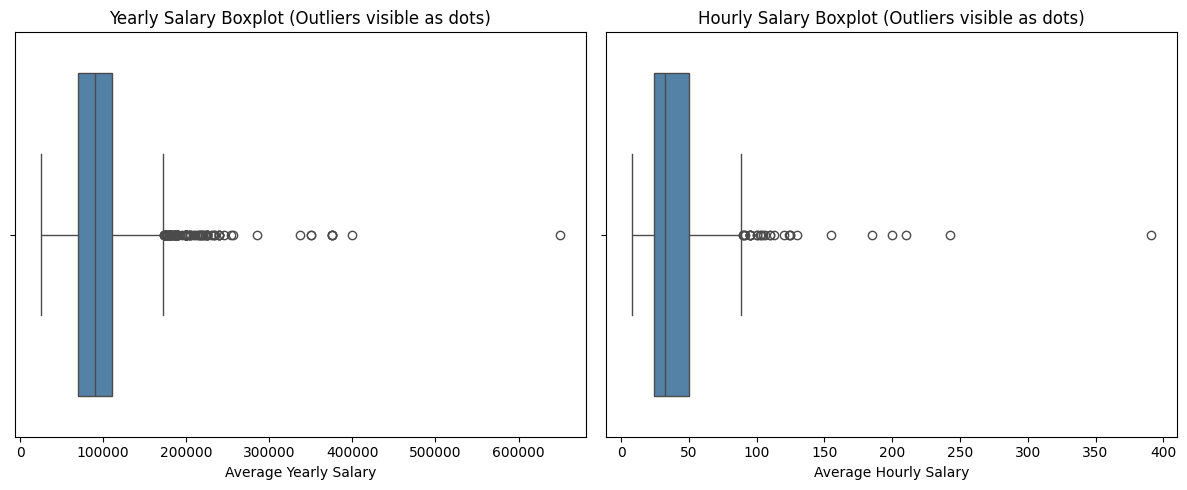

In [11]:
# Generate core statistical summaries for salary distributions
print("Summary Statistics for Salaries:")

# Compute descriptive statistics including mean, min, max, and quartiles
salary_stats = df[["salary_year_avg", "salary_hour_avg"]].describe().round(2)

# Display the formatted statistical overview for the panel
display(salary_stats)

print("\n" + "="*70 + "\n")

# Identify statistical outliers utilizing the Interquartile Range (IQR) method
print("Mathematical Outlier Calculation (IQR Method):")

# --- YEARLY SALARIES ---
Q1_year, Q3_year = df["salary_year_avg"].quantile([0.25, 0.75])
IQR_year = Q3_year - Q1_year
upper_year = Q3_year + 1.5 * IQR_year
lower_year = Q1_year - 1.5 * IQR_year

# Isolate records falling outside the established upper and lower IQR boundaries
year_outliers = df[(df["salary_year_avg"] < lower_year) | (df["salary_year_avg"] > upper_year)]
print(f" -> Found {len(year_outliers)} Yearly Salary Outliers")

# --- HOURLY SALARIES ---
Q1_hour, Q3_hour = df["salary_hour_avg"].quantile([0.25, 0.75])
IQR_hour = Q3_hour - Q1_hour
upper_hour = Q3_hour + 1.5 * IQR_hour
lower_hour = Q1_hour - 1.5 * IQR_hour

# Isolate records falling outside the established upper and lower IQR boundaries
hour_outliers = df[(df["salary_hour_avg"] < lower_hour) | (df["salary_hour_avg"] > upper_hour)]
print(f" -> Found {len(hour_outliers)} Hourly Salary Outliers")

print("\n" + "="*70 + "\n")

# Visualize the salary distributions and highlight the calculated outliers
print("Visualizing the Outliers:")

# Initialize a side-by-side subplot grid for targeted boxplot comparisons
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Render the Yearly Salary boxplot to visually confirm calculated outliers
sns.boxplot(data=df, x="salary_year_avg", color="steelblue", ax=axes[0])
axes[0].set_title("Yearly Salary Boxplot (Outliers visible as dots)")
axes[0].set_xlabel("Average Yearly Salary")

# Render the Hourly Salary boxplot to visually confirm calculated outliers
sns.boxplot(data=df, x="salary_hour_avg", color="steelblue", ax=axes[1])
axes[1].set_title("Hourly Salary Boxplot (Outliers visible as dots)")
axes[1].set_xlabel("Average Hourly Salary")

# Apply layout optimization to ensure a clean presentation render
plt.tight_layout()
plt.show()

BEFORE: Calculating median salary using the raw, unstructured text


,Raw Schedule Text,Median Salary
0,Contractor,80925.000000
1,Contractor and Temp work,82500.000000
2,Full-time,90000.000000
3,Full-time and Contractor,78667.453125
4,Full-time and Internship,68000.000000




AFTER: Aggregating median salaries utilizing engineered boolean flags


,Job Schedule,Median Salary
0,Full-time,90000.00000
1,Part-time,84307.40625
5,Per diem,82010.50000
3,Contractor,80000.00000
4,Temp work,75000.00000
2,Internship,65000.00000


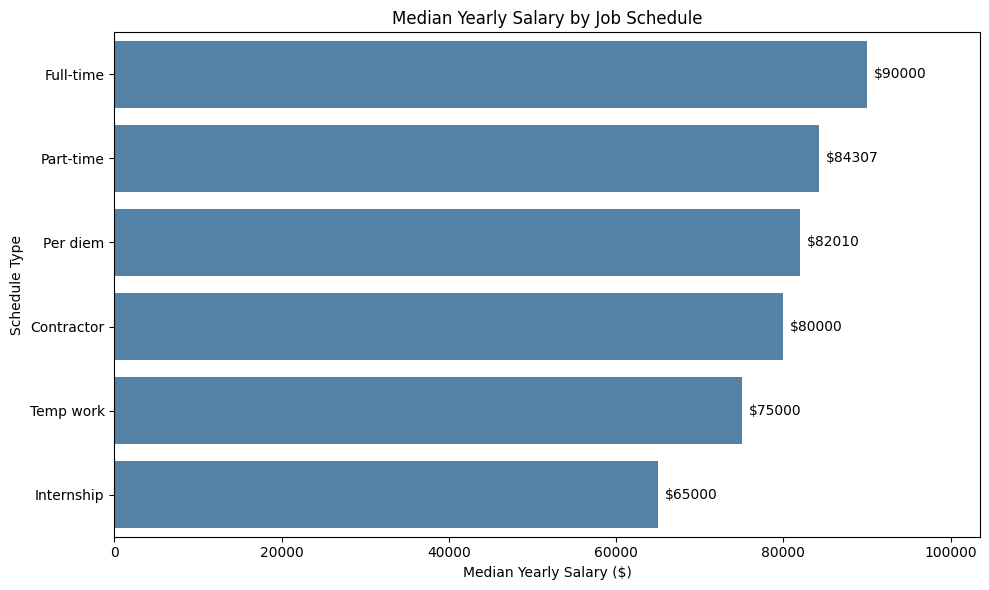

In [12]:
# Inspect the baseline salary aggregation using the original, uncleaned text column
print("BEFORE: Calculating median salary using the raw, unstructured text")

# Grouping by raw text creates highly fragmented and inaccurate categories (e.g., "Full-time, Part-time")
messy_median = df.groupby("job_schedule_type")["salary_year_avg"].median().dropna().head(5).to_frame().reset_index()
messy_median.columns = ["Raw Schedule Text", "Median Salary"]
display(messy_median)

print("\n" + "="*70 + "\n")

# Apply the engineered boolean flags to generate an accurate salary distribution
print("AFTER: Aggregating median salaries utilizing engineered boolean flags")

# Construct a refined summary table leveraging our custom boolean columns to ensure every job is counted
schedule_salary_summary = pd.DataFrame({
    "Job Schedule": schedule_types,
    "Median Salary": [df.loc[df["is_{}".format(s.lower().replace('-', '_').replace(' ', '_'))], "salary_year_avg"].median() for s in schedule_types]
})

# Sort the dataset descending by salary to establish a clear visual hierarchy
schedule_salary_summary = schedule_salary_summary.sort_values(by="Median Salary", ascending=False).dropna()

# Display the standardized, accurate summary table for the panel
display(schedule_salary_summary)

print("\n" + "="*70 + "\n")

# Visualize the final salary distribution by schedule type
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=schedule_salary_summary, x="Median Salary", y="Job Schedule", color="steelblue")

# Append formatted currency labels to each bar for precise financial reporting
# Apply padding to ensure typographic legibility at the edge of the data bars
ax.bar_label(ax.containers[0], fmt='$%.0f', padding=5)

# Dynamically extend the x-axis limit by 15% beyond the maximum value
# This ensures data labels render cleanly without truncation at the chart edge
max_salary = schedule_salary_summary["Median Salary"].max()
ax.set_xlim(0, max_salary * 1.15) 

# Apply professional formatting, axis labels, and layout optimization
plt.title("Median Yearly Salary by Job Schedule")
plt.xlabel("Median Yearly Salary ($)")
plt.ylabel("Schedule Type")
plt.tight_layout()

# Render the optimized visualization
plt.show()

Salary Statistics for the Top 10 Countries:


,Country,Total Jobs,Average Salary,Median Salary
9,United States,4362,94504.0,90000.0
7,Sudan,122,93441.0,90000.0
3,India,94,99150.0,100500.0
8,United Kingdom,72,89411.0,87750.0
1,France,51,82156.0,80850.0
2,Germany,48,101563.0,103750.0
5,Poland,43,87505.0,89100.0
4,Mexico,37,89536.0,98500.0
6,Portugal,37,94011.0,89100.0
0,Canada,31,91098.0,98500.0




Visualizing the Median Salaries:


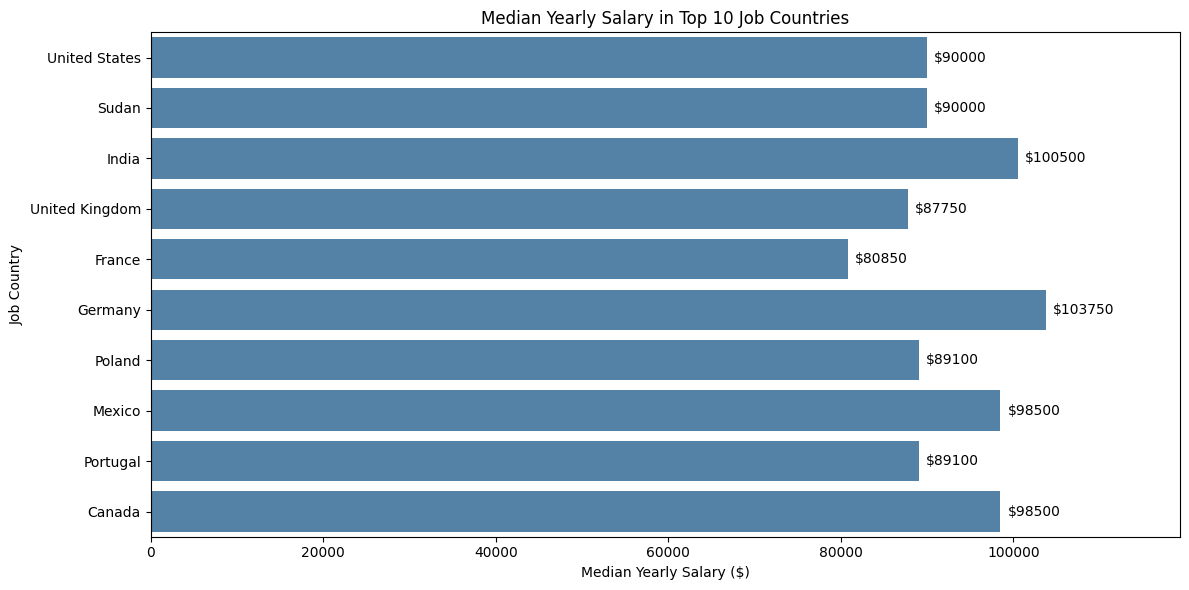

In [13]:
# Generate salary statistics for the top 10 highest-volume job markets
print("Salary Statistics for the Top 10 Countries:")

# Identify the top 10 countries by total job posting volume
top_countries = df["job_country"].value_counts().head(10).index

# Filter the dataset, aggregate by country, and compute core salary metrics
country_salary_summary = (
    df[df["job_country"].isin(top_countries) & df["salary_year_avg"].notna()]
    .groupby("job_country")["salary_year_avg"]
    .agg(["count", "mean", "median"])
    .reset_index()
    .sort_values("count", ascending=False)
)

# Apply professional column names to standardize the output table
country_salary_summary.columns = ["Country", "Total Jobs", "Average Salary", "Median Salary"]

# Render the formatted statistical summary table for the panel
display(country_salary_summary.round(0))

print("\n" + "="*70 + "\n")

# Visualize the median salary distribution across top international markets
print("Visualizing the Median Salaries:")

# Initialize a horizontal bar chart with optimized dimensions for readability
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=country_salary_summary, x="Median Salary", y="Country", color="steelblue")

# Append formatted currency labels to each bar for precise financial reporting
ax.bar_label(ax.containers[0], fmt='$%.0f', padding=5)

# Dynamically extend the x-axis limit by 15% beyond the maximum value
# This ensures data labels render cleanly without truncation at the chart edge
max_salary = country_salary_summary["Median Salary"].max()
ax.set_xlim(0, max_salary * 1.15) 

# Apply professional formatting, axis titles, and layout optimization
plt.title("Median Yearly Salary in Top 10 Job Countries")
plt.xlabel("Median Yearly Salary ($)")
plt.ylabel("Job Country")
plt.tight_layout()

# Display the finalized geographic salary visualization
plt.show()

Internship Dataset Shape: (92, 25)


,Job Country,Job Count
0,United States,85
1,Sudan,3
2,Colombia,2
3,India,1
4,Netherlands,1


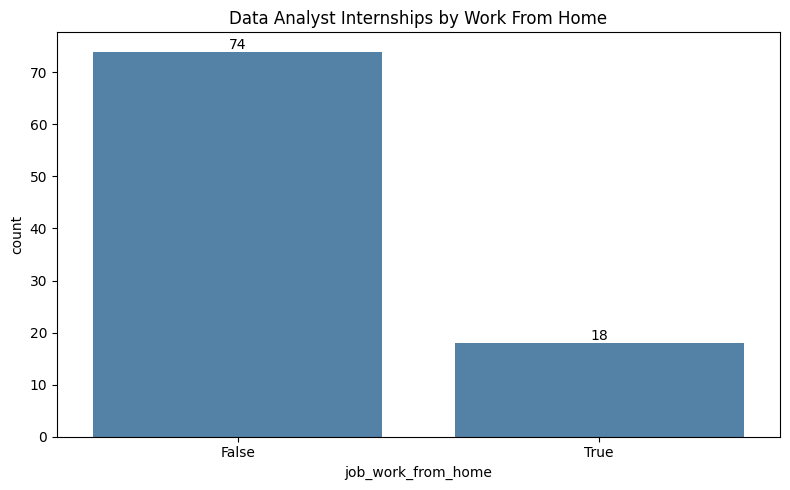

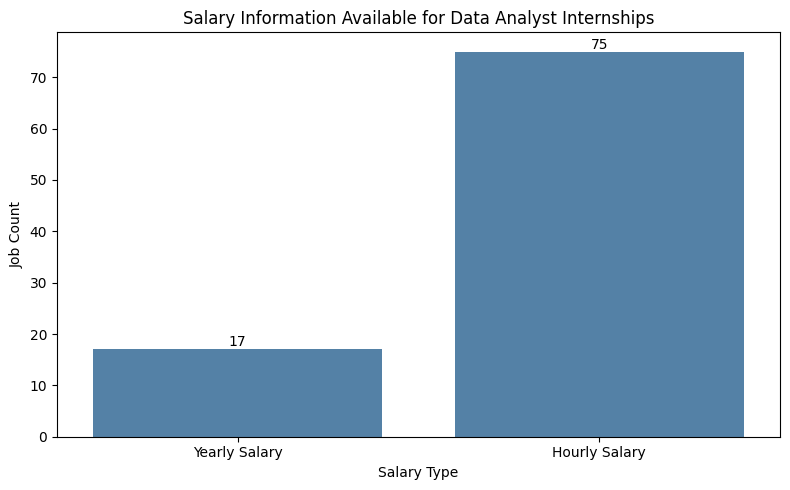

In [14]:
# Filter the primary dataset to isolate early-career internship opportunities
internship_df = df[df["is_internship"]].copy()
print("Internship Dataset Shape:", internship_df.shape)

# Identify the highest-volume geographic markets for entry-level roles
internship_country = internship_df["job_country"].value_counts().head(10).reset_index()
internship_country.columns = ["Job Country", "Job Count"]
display(internship_country)

# Evaluate remote work flexibility specifically within the internship subset
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=internship_df, x="job_work_from_home", color="steelblue")

# Append precise data labels to the remote work distribution chart
ax.bar_label(ax.containers[0])

# Apply professional formatting and render the remote flexibility visualization
plt.title("Data Analyst Internships by Work From Home")
plt.tight_layout()
plt.show()

# Assess compensation transparency by analyzing how internship salaries are structured
internship_salary = pd.DataFrame({
    "Salary Type": ["Yearly Salary", "Hourly Salary"],
    "Job Count": [
        internship_df["salary_year_avg"].notna().sum(),
        internship_df["salary_hour_avg"].notna().sum()
    ]
})

# Initialize a visual comparison of salary reporting formats
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=internship_salary, x="Salary Type", y="Job Count", color="steelblue")

# Append exact reporting counts to support the transparency analysis
ax.bar_label(ax.containers[0])

# Apply final formatting and render the salary transparency chart
plt.title("Salary Information Available for Data Analyst Internships")
plt.tight_layout()
plt.show()